In [ ]:
"""
Reproducing: "Differentially Private Covariance Estimation"
Experiments from Section 4: compare Algorithm 1 vs Laplace / Gaussian / KT baselines
on Wine, Airfoil, Adult datasets.

Key implementation notes:
- This file follows the paper's convention `X in R^{d x n}`:
  columns are samples and rows are features.
- The goal here is lightweight trend-matching rather than exact paper-level reproduction.
- `true_covariance(X)` returns the paper-scale covariance `X X^T`
- All mechanisms return covariance estimates on the same unnormalized scale
- `dp_algorithm1` is a simplified iterative implementation aligned with `replication.ipynb`
"""

import argparse
import json
import time
import warnings
import torch

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from scipy.linalg import eigh
from scipy.optimize import root_scalar
from sklearn.datasets import fetch_california_housing, fetch_openml, load_breast_cancer, load_digits, load_wine

warnings.filterwarnings("ignore")


SAMPLER_MODE = "auto"


def set_sampler_mode(mode):
    """Set the eigenvector sampler used by KT and Algorithm 1."""
    global SAMPLER_MODE
    if mode not in {"simple", "acg", "auto"}:
        raise ValueError(f"Unsupported sampler mode: {mode}")
    SAMPLER_MODE = mode


# ---------------------------------------------------------------------------
# 1. Data loading and preprocessing
# ---------------------------------------------------------------------------


def _show_progress(step, total, label):
    """Print a simple one-line progress bar for long dataset preparation steps."""
    width = 28
    filled = int(width * step / total)
    bar = "#" * filled + "-" * (width - filled)
    pct = int(100 * step / total)
    print(f"\r[{bar}] {pct:3d}% {label}", end="", flush=True)
    if step == total:
        print()

def load_and_preprocess(path, sep=",", header="infer"):
    df = pd.read_csv(path, sep=sep, header=header)
    X = df.values.astype(float)

    # Input tables are loaded in the standard ML layout (n x d).
    # We standardize feature-columns, then transpose to the paper's d x n layout
    # where each column is one sample, and finally normalize each sample-column.
    X = X[:, X.std(axis=0) > 0]
    X = (X - X.mean(axis=0)) / X.std(axis=0)
    X = X.T
    col_norms = np.linalg.norm(X, axis=0, keepdims=True)
    X = X / col_norms
    return X


def _standardize_and_normalize(df):
    X = df.values.astype(float)
    X = X[:, X.std(axis=0) > 0]
    X = (X - X.mean(axis=0)) / X.std(axis=0)
    X = X.T                      # d x n
    col_norms = np.linalg.norm(X, axis=0, keepdims=True)
    X = X / np.maximum(col_norms, 1e-12)   # exact unit-norm normalization
    return X

def load_wine_appendix():
    """Wine dataset used in the supplement: sklearn's 13-feature wine data."""
    X, _ = load_wine(return_X_y=True, as_frame=True)
    return _standardize_and_normalize(X)


def load_airfoil_appendix():
    """Airfoil data from the local CSV, matching the 6-column setup in the supplement."""
    df = pd.read_csv("data/airfoil.csv", header=None)
    return _standardize_and_normalize(df)


def load_breast_cancer_appendix():
    """Breast Cancer Wisconsin dataset: d=30, n=569. sklearn built-in."""
    X, _ = load_breast_cancer(return_X_y=True, as_frame=True)
    return _standardize_and_normalize(X)


def load_digits_appendix():
    """Digits dataset: d=64, n=1797. sklearn built-in."""
    X, _ = load_digits(return_X_y=True, as_frame=True)
    return _standardize_and_normalize(X)


def load_california_housing_appendix():
    """California Housing dataset: d=8, n=20640. sklearn built-in."""
    data = fetch_california_housing(as_frame=True)
    return _standardize_and_normalize(data.data)


def load_volkert_appendix():
    """
    Volkert dataset from OpenML (ID 41166).

    A ChaLearn AutoML challenge dataset with 180 numerical features and 58,310
    samples. Features are already numerical and complete (no missing values),
    making it a clean high-dimensional tabular benchmark (d=180).
    """
    total_steps = 4
    cache_dir = "data/.sk_cache"
    _show_progress(0, total_steps, "Volkert: fetching OpenML dataset")
    volkert = fetch_openml(data_id=41166, as_frame=True, data_home=cache_dir)
    _show_progress(1, total_steps, "Volkert: extracting numerical features")
    X = volkert.data.copy().select_dtypes(include="number")
    _show_progress(2, total_steps, "Volkert: standardizing features")
    return_val = _standardize_and_normalize(X)
    _show_progress(3, total_steps, "Volkert: transposing and clipping samples")
    _show_progress(4, total_steps, f"Volkert: ready with shape {return_val.shape}")
    return return_val


def load_adult_appendix():
    """
    Adult dataset aligned to the supplement as closely as possible.

    We use the standard OpenML Adult dataset and one-hot encode categorical columns.
    This yields 105 features in this encoding, which is the closest standard local
    representation available to the supplement's reported 108-dimensional setup.
    """
    total_steps = 5
    cache_dir = "data/.sk_cache"
    _show_progress(0, total_steps, "Adult: fetching OpenML dataset")
    adult = fetch_openml("adult", version=2, as_frame=True, data_home=cache_dir)
    _show_progress(1, total_steps, "Adult: copying raw frame")
    X = adult.data.copy()
    _show_progress(2, total_steps, "Adult: one-hot encoding categorical columns")
    X = pd.get_dummies(X, drop_first=False)
    _show_progress(3, total_steps, "Adult: standardizing features")
    X = X.values.astype(float)
    X = X[:, X.std(axis=0) > 0]
    X = (X - X.mean(axis=0)) / X.std(axis=0)
    _show_progress(4, total_steps, "Adult: transposing and clipping samples")
    X = X.T
    col_norms = np.linalg.norm(X, axis=0, keepdims=True)
    X = X / np.maximum(col_norms, 1e-12)
    _show_progress(5, total_steps, f"Adult: ready with shape {X.shape}")
    return X


def subsample(X, n, rng):
    idx = rng.choice(X.shape[1], size=min(n, X.shape[1]), replace=False)
    return X[:, idx]


# ---------------------------------------------------------------------------
# 2. Covariance matrices
# ---------------------------------------------------------------------------

def true_covariance(X):
    """Paper-scale covariance used as the reference for error evaluation."""
    return X @ X.T


def gram_matrix(X):
    """Unnormalized covariance matrix used internally by the DP algorithms.
    """
    return X @ X.T


# ---------------------------------------------------------------------------
# 3. Evaluation metric
# ---------------------------------------------------------------------------

def frobenius_error(C_true, C_hat, n):
    # Paper (Sec 4): normalized Frobenius distance  ||C_hat - C||_F / n
    return np.linalg.norm(C_true - C_hat, "fro") / n


def _clip_eigenvalues_to_data_bound(C_hat, n):
    """Clip eigenvalues to [0, n] as in the paper's post-processing step."""
    eigvals, eigvecs = eigh(C_hat)
    eigvals = np.clip(eigvals, 0.0, float(n))
    return eigvecs @ np.diag(eigvals) @ eigvecs.T


def _clip_psd_full(C_hat, n):
    """Project a covariance estimate onto the PSD cone and clip eigenvalues to [0, n]."""
    # Symmetrize first to absorb any floating-point asymmetry
    C_hat = (C_hat + C_hat.T) / 2.0
    eigvals, eigvecs = eigh(C_hat)
    eigvals = np.clip(eigvals, 0.0, float(n))
    return eigvecs @ np.diag(eigvals) @ eigvecs.T


def _sample_exponential_mechanism(C, epsilon, rng, num_candidates=500):
    """
    Lightweight approximation of the exponential mechanism on the sphere.

    Paper (Sec 2 / Alg 1 Step 2a): the exact sampler draws u from the density
        f_{C_i}(u)  ∝  exp( (epsilon_i / 4) * u^T C_i u )   on S^{d-1}
    which is a Bingham distribution.  The factor 4 in the denominator comes
    from the exponential-mechanism sensitivity: for unit-norm columns,
        |g(XX^T, θ) - g(X̃X̃^T, θ)| = |θ^T(xx^T - x̃x̃^T)θ| ≤ 2,
    so Lemma 4 gives density ∝ exp( eps * g / (2*Δ_g) ) = exp( eps*u^TCu / 4 ).

    The exact sampler is Algorithm 2 (Kent et al. rejection sampler, Sec 3.2).
    This implementation replaces it with a Monte-Carlo softmax over
    `num_candidates` uniform unit vectors — cheaper but approximate.
    """
    d = C.shape[0]
    # Draw uniform random unit vectors on S^{d-1}
    candidates = rng.standard_normal((num_candidates, d))
    candidates /= np.linalg.norm(candidates, axis=1, keepdims=True)
    # Utility score: g(C, u) = u^T C u  (Alg 1 Step 2a)
    scores = np.einsum("ij,jk,ik->i", candidates, C, candidates)
    # Weights ∝ exp( (epsilon_i / 4) * u^T C u )  — exact density up to normalizer
    logits = (epsilon / 4.0) * scores
    logits -= np.max(logits)   # numerical stability
    weights = np.exp(logits)
    weights /= np.sum(weights)
    return candidates[rng.choice(num_candidates, p=weights)]


def _solve_acg_b(eigvals_a):
    """Solve the saddle-point equation for Algorithm 2's ACG proposal."""
    lower = max(1e-12, -2.0 * float(np.min(eigvals_a)) + 1e-12)

    def f(val):
        return np.sum(1.0 / (val + 2.0 * eigvals_a)) - 1.0

    upper = max(lower * 2.0, 1.0)
    for _ in range(80):
        if f(upper) <= 0:
            break
        upper *= 2.0
    else:
        raise RuntimeError("Failed to bracket Algorithm 2 saddle-point parameter b.")

    for _ in range(100):
        mid = 0.5 * (lower + upper)
        if f(mid) > 0:
            lower = mid
        else:
            upper = mid
    return 0.5 * (lower + upper)


def _sample_exponential_mechanism_acg(C, epsilon, rng, num_candidates=500, max_attempts=2000):
    """
    Algorithm 2-style rejection sampler with an ACG proposal.

    The extracted supplement formula for b is numerically inconsistent on this
    problem family. We therefore use the standard saddle-point condition
    sum_i 1 / (b + 2 lambda_i(A)) = 1 to obtain a valid positive proposal
    parameter, and fall back to the original Monte-Carlo approximation if the
    rejection sampler becomes numerically unstable.
    """
    d = C.shape[0]
    if d == 1:
        return np.array([1.0])

    try:
        eigvals_c = eigh(C, eigvals_only=True)
        lam_min = float(eigvals_c[0])
        A = -(epsilon / 4.0) * C + (epsilon / 4.0) * lam_min * np.eye(d)
        eigvals_a = eigh(A, eigvals_only=True)
        b = _solve_acg_b(eigvals_a)
        Omega = np.eye(d) + (2.0 / b) * A
        Omega = (Omega + Omega.T) / 2.0
        chol = np.linalg.cholesky(Omega)
        log_m = -(d - b) / 2.0 + (d / 2.0) * np.log(d / b)

        for _ in range(max_attempts):
            z = np.linalg.solve(chol, rng.standard_normal(d))
            norm_z = np.linalg.norm(z)
            if norm_z == 0:
                continue
            u = z / norm_z
            quad_a = float(u @ A @ u)
            quad_o = float(u @ Omega @ u)
            log_accept = -quad_a - log_m - (d / 2.0) * np.log(max(quad_o, 1e-300))
            if np.log(rng.uniform()) <= min(0.0, log_accept):
                return u
    except (np.linalg.LinAlgError, RuntimeError, FloatingPointError):
        pass

    return _sample_exponential_mechanism(C, epsilon, rng, num_candidates=num_candidates)


def _sample_eigenvector(C, epsilon, rng, sampler_mode=None):
    """Dispatch between the simple and ACG-style samplers."""
    mode = SAMPLER_MODE if sampler_mode is None else sampler_mode
    if mode == "simple":
        return _sample_exponential_mechanism(C, epsilon, rng)
    if mode == "acg":
        return _sample_exponential_mechanism_acg(C, epsilon, rng)
    if mode == "auto":
        return _sample_exponential_mechanism_acg(C, epsilon, rng)
    raise ValueError(f"Unsupported sampler mode: {mode}")


# ---------------------------------------------------------------------------
# 4. Laplace baseline
# ---------------------------------------------------------------------------

def _rank_k_psd(C_noisy, k, n):
    """Top-k eigendecomposition with non-negative eigenvalue clipping."""
    d = C_noisy.shape[0]
    eigvals, eigvecs = eigh(C_noisy)
    C_hat = np.zeros((d, d))
    for i in range(d - 1, d - 1 - k, -1):
        eigval = eigvals[i]
        if eigval > 0:
            C_hat += min(eigval, float(n)) * np.outer(eigvecs[:, i], eigvecs[:, i])
    return _clip_eigenvalues_to_data_bound(C_hat, n)


# def _rank_k_psd_normalized(C_hat, k):
#     """Apply the same top-k PSD clipping to an already normalized matrix."""
#     d = C_hat.shape[0]
#     eigvals, eigvecs = eigh(C_hat)
#     C_rank_k = np.zeros((d, d))
#     for i in range(d - 1, d - 1 - k, -1):
#         eigval = min(max(eigvals[i], 0.0), 1.0)
#         if eigval > 0:
#             C_rank_k += eigval * np.outer(eigvecs[:, i], eigvecs[:, i])
#     return _clip_normalized_eigenvalues(C_rank_k)


def dp_laplace(X, epsilon, k, rng):
    """Laplace mechanism baseline (Sec 4, baseline 'L').

    Paper (Sec 2, Laplace Mechanism): add i.i.d. Lap(Δ_f / ε) noise to each
    output coordinate, where Δ_f is the l1-sensitivity of the query.

    For C = XX^T the l1-sensitivity of any single entry C_{ij} = Σ_k x_ik x_jk
    scales as O(d) when column norms are 1, giving scale = 2d / epsilon.
    The factor 2 comes from the sensitivity being bounded by 2 (removing one
    column changes each entry by at most 2 * 1 * 1 = 2 in absolute value,
    and summing over d rows gives the l1-sensitivity of 2d).
    """
    del k  # Laplace acts on the full matrix; rank truncation is not used
    d, n = X.shape
    C = gram_matrix(X)                                    # C = XX^T  (Sec 2)
    noise = rng.laplace(0.0, (2.0 * d) / epsilon, C.shape)  # Lap(2d / ε) per entry
    noise = (noise + noise.T) / 2                         # symmetrize noise matrix
    return _clip_psd_full(C + noise, n)


# ---------------------------------------------------------------------------
# 5. Gaussian baseline
# ---------------------------------------------------------------------------

def dp_gaussian(X, epsilon, delta, k, rng):
    """Gaussian mechanism baseline (Sec 3.1, baseline 'G').

    Paper (Sec 3.1): the Gaussian mechanism achieves (ε, δ)-DP and has the
    error bound:
        ||C - Ĉ||_F  ≤  O( d^{3/2} * sqrt(log(1/δ)) / ε )

    The noise scale σ = d^{3/2} * sqrt(log(1/δ)) / ε follows from calibrating
    the Gaussian mechanism to the Frobenius (l2) sensitivity of C = XX^T.
    Evaluated in experiments at δ ∈ {1e-16, 1e-10, 1e-3} (Sec 4).
    """
    del k  # Gaussian acts on the full matrix; rank truncation is not used
    _, n = X.shape
    C = gram_matrix(X)                                    # C = XX^T  (Sec 2)
    d = C.shape[0]
    # σ = d^{3/2} * sqrt(log(1/δ)) / ε  (Sec 3.1 Gaussian bound)
    sigma = (d ** 1.5 * np.sqrt(np.log(1.0 / delta))) / epsilon
    noise = rng.standard_normal(C.shape)
    noise = (noise + noise.T) / 2                         # symmetrize noise matrix
    return _clip_psd_full(C + sigma * noise, n)


# ---------------------------------------------------------------------------
# 6. KT baseline
# ---------------------------------------------------------------------------

def dp_kt(X, epsilon, delta, k, rng, sampler_mode=None):
    """Kapralov-Talwar (KT) baseline — pure ε-DP (Sec 4, baseline 'KT').

    Paper (Sec 4 / Corollary 2): KT iterates k rounds of rank-one subtraction.
    Each round splits its budget equally between eigenvector sampling and
    eigenvalue estimation:
        ε_per  = ε / k          (budget per round, by composition, Lemma 2)
        ε_ev   = ε_per / 2      (for exponential-mechanism eigenvector)
        ε_lam  = ε_per / 2      (for Laplace-noisy eigenvalue)

    Unlike Algorithm 1, the residual is updated by *subtracting* the rank-1
    term (C_s ← C_s - λ g g^T) rather than projecting onto the orthogonal
    complement.  This is the key structural difference discussed in Sec 3.2.
    """
    del delta  # KT is pure ε-DP; δ is not used
    if rng is None:
        rng = np.random.default_rng()

    d, n = X.shape
    if k is None:
        k = d  # default: full-rank reconstruction

    C_s = gram_matrix(X).copy()   # C_s: residual matrix, starts at C = XX^T
    C_hat = np.zeros((d, d))

    # Budget split: ε_per = ε/k per round (Lemma 2 composition over k rounds)
    eps_per = epsilon / k
    eps_ev  = eps_per / 2.0   # eigenvector budget (exponential mechanism)
    eps_lam = eps_per / 2.0   # eigenvalue budget  (Laplace mechanism)

    for _ in range(k):
        # Step: sample top eigenvector of residual via exponential mechanism
        # density ∝ exp( (ε_ev/4) * u^T C_s u )  (Alg 1 Step 2a, sensitivity 2)
        g = _sample_eigenvector(C_s, eps_ev, rng, sampler_mode=sampler_mode)

        # Noisy eigenvalue: λ̂ = g^T C_s g + Lap(1/ε_lam)
        # Lap scale = 1/ε_lam because sensitivity of g^T C g is 1 for unit g
        lam = float(g @ C_s @ g) + rng.laplace(0.0, 1.0 / eps_lam)
        lam = max(lam, 0.0)          # clip to non-negative (paper: eigenvalue rounding)

        C_hat += lam * np.outer(g, g)         # accumulate rank-1 term
        C_s = C_s - lam * np.outer(g, g)     # subtract rank-1 term from residual
        C_s = (C_s + C_s.T) / 2.0            # re-symmetrize after subtraction

    # Ĉ = (1/n) * Σ_i λ̂_i g_i g_i^T,  then clip to PSD  (Sec 4)
    return _clip_psd_full(C_hat, n)


# ---------------------------------------------------------------------------
# 7. Algorithm 1: Iterative Eigenvector Sampling
# ---------------------------------------------------------------------------



def _orth_complement(g):
    """Return an orthonormal basis for the subspace orthogonal to unit vector g.

    Paper (Alg 1 Step 2b): after sampling θ̂_i, update P_{i+1} as an
    orthonormal basis of {θ̂_1,...,θ̂_i}⊥.  Done incrementally here: given
    the current direction g (= û_i in the reduced subspace), columns 1..end
    of the full left-singular-vector matrix of g span g⊥.
    """
    # SVD of g as a column vector: U[:,0] = g,  U[:,1:] spans g⊥
    U, _, _ = np.linalg.svd(g.reshape(-1, 1), full_matrices=True)
    return U[:, 1:]   # shape (d-i) × (d-i-1): orthonormal basis of û_i⊥


def _algorithm1_privacy_split(C, epsilon, rng, beta=0.01, adaptive=False):
    """Compute noisy eigenvalues and per-round privacy budgets for Algorithm 1.

    Paper (Alg 1 Step 1 + Corollary 1 / Supplement IT-U):

    Step 1 (shared by both variants):
        ε_0 = ε / 2
        λ̂_i = λ_i(C) + Lap(2 / ε_0)  for i=1,...,d
        Scale 2/ε_0: l1-sensitivity of eigenvalue vector ≤ 2
        (Theorem 1 proof: ||Λ(XX^T)-Λ(X̃X̃^T)||_1 = tr(xx^T) ≤ 1, so ≤ 2).

    Adaptive split — Corollary 1 ('AD'):
        τ  = (2 / ε_0) * log(2d / β)
        ε_i = (ε/2) * sqrt(λ̂_i + τ) / Σ_j sqrt(λ̂_j + τ)
        Total: ε_0 + Σ ε_i = ε/2 + ε/2 = ε  ✓

    Uniform split — Supplement IT-U:
        ε_i = ε / (2d)  for all i
        Total: ε_0 + d*(ε/2d) = ε/2 + ε/2 = ε  ✓
    """
    d = C.shape[0]
    eps0 = epsilon / 2.0                    # ε_0 = ε/2  (Corollary 1)

    eigvals, _ = eigh(C)
    eigvals = eigvals[::-1]                 # descending order: λ_1 ≥ ... ≥ λ_d
    # Alg 1 Step 1: λ̂_i = λ_i(C) + Lap(2/ε_0)
    noisy_eigvals = eigvals + rng.laplace(0.0, 2.0 / eps0, size=d)

    if adaptive:
        # Corollary 1: τ = (2/ε_0)*log(2d/β) = (4/ε)*log(2d/β)
        tau = (2.0 / eps0) * np.log(2.0 * d / beta)
        weights = np.sqrt(np.maximum(noisy_eigvals + tau, 1e-12))
        # ε_i = (ε/2) * w_i / Σ_j w_j,  where w_i = sqrt(λ̂_i + τ)
        eps_rounds = (epsilon / 2.0) * weights / np.sum(weights)
    else:
        # IT-U: uniform ε_i = ε/(2d) for all i  (Supplement)
        eps_rounds = np.full(d, epsilon / (2.0 * d))

    return noisy_eigvals, eps_rounds


def _dp_algorithm1_core(X, epsilon, rng=None, beta=0.01, adaptive=False, rank_k=None, sampler_mode=None):
    """Core of Algorithm 1: Iterative Eigenvector Sampling (Sec 3).

    Full pseudocode from paper:

        Input:  C = XX^T,  params ε_0, ε_1, ..., ε_d

        Step 1. λ̂_i = λ_i(C) + Lap(2/ε_0)  for i=1,...,d   [← _algorithm1_privacy_split]
                C_1 = C,  P_1 = I_d

        Step 2. For i = 1,...,d:
          (a) û_i ~ exp( (ε_i/4) * u^T C_i u ) on S^{d-i}   [← _sample_exponential_mechanism]
              θ̂_i = P_i^T û_i                               (lift to R^d)
          (b) P_{i+1}: orthonormal basis ⊥ to {θ̂_1,...,θ̂_i} [← _orth_complement]
          (c) C_{i+1} = P_{i+1} C P_{i+1}^T  ∈ R^{(d-i)×(d-i)}

        Step 3. Output Ĉ = Σ_i λ̂_i θ̂_i θ̂_i^T / n  (then clip to PSD)

    Privacy (Theorem 1): preserves (Σ_{i=0}^d ε_i)-DP by composition (Lemma 2).
    Utility (Theorem 2): ||C - Ĉ||_F ≤ Õ(sqrt(Σ_i d*λ_i/ε_i + sqrt(d)/ε_0)).
    Rank-k variant (after Theorem 2): stop loop at i=k; distance from best rank-k approx.
    """
    if rng is None:
        rng = np.random.default_rng()

    d, n = X.shape
    # Step 1: C = XX^T  (Sec 2 input convention)
    C = gram_matrix(X)
    # Compute λ̂_i and ε_i for all rounds  (Alg 1 Step 1 + Corollary 1)
    noisy_eigvals, eps_rounds = _algorithm1_privacy_split(
        C, epsilon, rng, beta=beta, adaptive=adaptive
    )
    # Rank-k truncation: run only k rounds (Theorem 2 rank-k variant)
    n_rounds = d if rank_k is None else min(rank_k, d)
    noisy_eigvals = noisy_eigvals[:n_rounds]
    eps_rounds    = eps_rounds[:n_rounds]

    # Step 1 init: P_1 = I_d (columns are the current subspace basis in R^d)
    P_i = np.eye(d)   # P_i ∈ R^{d×(d-i+1)}: orthonormal basis of working subspace
    C_i = C.copy()    # C_i = P_i C P_i^T ∈ R^{(d-i+1)×(d-i+1)}, starts as C
    thetas = []

    for i in range(n_rounds):
        # Step 2a: û_i ~ exp. mechanism on S^{d-i} with budget ε_i
        u_i = _sample_eigenvector(C_i, eps_rounds[i], rng, sampler_mode=sampler_mode)
        # θ̂_i = P_i^T û_i  — lift û_i from subspace coords back to R^d
        # (note: P_i stored as d×(d-i+1), so P_i @ u_i gives the R^d vector)
        theta_i = P_i @ u_i
        thetas.append(theta_i)

        if C_i.shape[0] == 1:
            break  # 1-dim subspace: nothing left to decompose

        # Step 2b: P_{i+1} — append one more orthogonal direction removed
        P_i = P_i @ _orth_complement(u_i)      # P_{i+1} = P_i * orth(û_i)
        # Step 2c: project C into new (d-i-1)-dim subspace
        C_i = P_i.T @ C @ P_i                  # C_{i+1} = P_{i+1} C P_{i+1}^T

    # Step 3: Ĉ = Σ_i λ̂_i θ̂_i θ̂_i^T  (Alg 1 Step 3)
    C_hat = np.zeros((d, d))
    for lam, theta in zip(noisy_eigvals, thetas):
        C_hat += lam * np.outer(theta, theta)
    # Project to PSD and clip eigenvalues to [0, n] (Sec. 4 post-processing).
    return _clip_psd_full(C_hat, n)


def dp_algorithm1_uniform(X, epsilon, delta, k, rng=None, beta=0.01, sampler_mode=None):
    """
    Appendix IT-U variant: uniform privacy splitting for Algorithm 1.
    """
    del delta, k
    return _dp_algorithm1_core(X, epsilon, rng=rng, beta=beta, adaptive=False, sampler_mode=sampler_mode)


def dp_algorithm1_adaptive(X, epsilon, delta, k, rng=None, beta=0.01, sampler_mode=None):
    """
    Appendix AD variant: adaptive privacy splitting following Corollary 1.
    """
    del delta
    return _dp_algorithm1_core(
        X, epsilon, rng=rng, beta=beta, adaptive=True, rank_k=k, sampler_mode=sampler_mode
    )


def dp_algorithm1_strict(X, epsilon, delta, k, rng=None, sampler_mode=None):
    """
    Backwards-compatible alias for the appendix IT-U/full-reconstruction version.
    """
    return dp_algorithm1_uniform(X, epsilon, delta, k, rng=rng, sampler_mode=sampler_mode)


def dp_algorithm1(X, epsilon, delta, k, rng=None, sampler_mode=None):
    """
    Main Algorithm 1 entry point used in experiments: appendix AD variant.
    """
    return dp_algorithm1_adaptive(X, epsilon, delta, k, rng=rng, sampler_mode=sampler_mode)


def dp_algorithm1_rank_k(X, epsilon, delta, k, rng=None, sampler_mode=None):
    """
    Rank-k post-processing wrapper around the main Algorithm 1 variant.
    """
    return dp_algorithm1(X, epsilon, delta, k, rng=rng, sampler_mode=sampler_mode)



# ---------------------------------------------------------------------------
# ** Devided (2022 version) -- utils **
# ---------------------------------------------------------------------------
def convert_symm_mat(ZZ, d):
    S = torch.empty([d, d])
    k = 0
    for i in range(d):
        for j in range(i, d):
            S[i, j] = ZZ[0, k]
            k += 1
    for i in range(d):
        for j in range(i + 1, d):
            S[j, i] = S[i, j]
    return S

def get_gauss_wigner_matrix(d):
    Z = torch.normal(0, 1, size=(1, int(d * (d + 1) / 2)))
    return convert_symm_mat(Z, d)

def get_gauss_noise_vector(d):
    return torch.normal(0, 1, size=(d,))

def rho_eps_eq(x, eps0, delta):
    f = x + 2 * np.sqrt(x * np.log(1. / delta))
    return f - eps0

def get_rho(eps, delta):
    if delta <= 0: return eps
    try:
        return root_scalar(rho_eps_eq, args=(eps, delta), bracket=[0, eps]).root
    except:
        return eps**2 / (2 * np.log(1.25/delta))

# ---------------------------------------------------------------------------
# ** Devided (2022 version) -- algos: GaussCov & SeparateCov **
# ---------------------------------------------------------------------------
def GaussCov_2022(X_torch, n, d, rho, delta=0.0, r=1.0, b_fleig=True):
    cov = torch.mm(X_torch.t(), X_torch) / n
    W = get_gauss_wigner_matrix(d)
    sens = np.sqrt(2) * r * r / n
    # zCDP noise scaling
    cov_tilde = cov + (sens / np.sqrt(2 * rho)) * W
    if b_fleig:
        D, U = torch.linalg.eigh(cov_tilde)
        D = torch.clamp(D, 0, r * r)
        cov_tilde = torch.mm(U, torch.mm(D.diag_embed(), U.t()))
    return cov_tilde

def SeparateCov_2022(X_torch, n, d, rho, r=1.0, b_fleig=True):
    cov = torch.mm(X_torch.t(), X_torch) / n
    rho0 = 0.5 * rho
    # use half buget to estimate direction (GaussCov)
    cov_gauss = GaussCov_2022(X_torch, n, d, rho0, r=r, b_fleig=False)
    Ug, _, _ = torch.linalg.svd(cov_gauss)
    # calculate eigenvalues on this direction and add noise
    D = torch.diag(torch.mm(Ug.t(), torch.mm(cov, Ug)))
    Z = get_gauss_noise_vector(d)
    sens = r * r * np.sqrt(2) / n
    D_tilde = D + (sens / np.sqrt(rho0) * Z)
    if b_fleig:
        D_tilde = torch.clamp(D_tilde, 0, r * r)
    return torch.mm(Ug, torch.mm(D_tilde.diag_embed(), Ug.t()))

# ---------------------------------------------------------------------------
# Gather 2022 to experiment
# ---------------------------------------------------------------------------
def dp_trace_algo_2022(X_dn, epsilon, delta, k, rng=None):
    """2022 Trace-Sensitive (Algorithm 1 变体)"""
    d, n = X_dn.shape
    X_torch = torch.from_numpy(X_dn.T).float()
    rho = get_rho(epsilon, delta)
    # Trace-Sensitive: use GaussCov optimized by trace estimation
    res_torch = GaussCov_2022(X_torch, n, d, rho, delta=delta, r=1.0)
    return res_torch.detach().numpy() * n # return to XX^T format

def dp_tail_algo_2022(X_dn, epsilon, delta, k, rng=None):
    """2022 Tail-Sensitive (Algorithm 2 变体)"""
    d, n = X_dn.shape
    X_torch = torch.from_numpy(X_dn.T).float()
    rho = get_rho(epsilon, delta)
    # SeparateCov
    res_torch = SeparateCov_2022(X_torch, n, d, rho, r=1.0)
    return res_torch.detach().numpy() * n

# ---------------------------------------------------------------------------
# 8. Experiment runners
# ---------------------------------------------------------------------------

def run_experiment_vary_n(X_full, ns, epsilon, delta, k, n_trials=5, seed=42):
    results = {alg: [] for alg in ["Laplace", "Gaussian", "KT", "Alg1"]}
    for n in ns:
        errs = {alg: [] for alg in results}
        for trial in range(n_trials):
            rng = np.random.default_rng(seed + trial)
            X = subsample(X_full, n, rng)
            C_true = true_covariance(X)
            errs["Laplace"].append(frobenius_error(C_true, dp_laplace(X, epsilon, k, rng), X.shape[1]))
            errs["Gaussian"].append(frobenius_error(C_true, dp_gaussian(X, epsilon, delta, k, rng), X.shape[1]))
            errs["KT"].append(frobenius_error(C_true, dp_kt(X, epsilon, delta, k, rng), X.shape[1]))
            errs["Alg1"].append(frobenius_error(C_true, dp_algorithm1_rank_k(X, epsilon, delta, k, rng=rng), X.shape[1]))
            # 2022 algos
            errs["Trace"].append(frobenius_error(C_true, dp_trace_algo_2022(X, epsilon, delta, k), n))
            errs["Tail"].append(frobenius_error(C_true, dp_tail_algo_2022(X, epsilon, delta, k), n))
        for alg in results:
            results[alg].append(np.mean(errs[alg]))
        print(f"  n={n}: done")
    return results


def run_experiment_vary_eps(X_full, epsilons, n, delta, k, n_trials=5, seed=42):
    results = {alg: [] for alg in ["Laplace", "Gaussian", "KT", "Alg1"]}
    for epsilon in epsilons:
        errs = {alg: [] for alg in results}
        for trial in range(n_trials):
            rng = np.random.default_rng(seed + trial)
            X = subsample(X_full, n, rng)
            C_true = true_covariance(X)
            errs["Laplace"].append(frobenius_error(C_true, dp_laplace(X, epsilon, k, rng), X.shape[1]))
            errs["Gaussian"].append(frobenius_error(C_true, dp_gaussian(X, epsilon, delta, k, rng), X.shape[1]))
            errs["KT"].append(frobenius_error(C_true, dp_kt(X, epsilon, delta, k, rng), X.shape[1]))
            errs["Alg1"].append(frobenius_error(C_true, dp_algorithm1_rank_k(X, epsilon, delta, k, rng=rng), X.shape[1]))
            # 2022 algos
            errs["Trace"].append(frobenius_error(C_true, dp_trace_algo_2022(X, epsilon, delta, k), n))
            errs["Tail"].append(frobenius_error(C_true, dp_tail_algo_2022(X, epsilon, delta, k), n))
        for alg in results:
            results[alg].append(np.mean(errs[alg]))
        print(f"  eps={epsilon}: done")
    return results


def run_experiment_vary_eps_gaussian_grid(
    X_full,
    epsilons,
    n,
    gaussian_deltas,
    k,
    n_trials=5,
    seed=42,
):
    """
    Supplement-style comparison:
    panel (a) uses Laplace / KT / Alg1,
    panel (b) compares Alg1 against several Gaussian deltas.

    Returns results_a, results_b, timing where timing maps algorithm name
    to total wall-clock seconds across all calls.
    """
    results_a = {alg: [] for alg in ["Laplace", "KT", "ITU", "Alg1", "Trace", "Tail"]}
    results_b = {f"G-{int(np.log10(delta))}": [] for delta in gaussian_deltas}
    results_b["Alg1"] = []
    results_b["Trace"] = []
    results_b["Tail"] = []

    # Accumulate total time and call count per algorithm
    time_totals = {alg: 0.0 for alg in ["Laplace", "Gaussian", "KT", "ITU", "Alg1", "Trace", "Tail"]}
    time_counts = {alg: 0 for alg in time_totals}

    total_runs = len(epsilons) * n_trials
    completed_runs = 0

    for eps_idx, epsilon in enumerate(epsilons, start=1):
        errs_a = {alg: [] for alg in results_a}
        errs_b = {alg: [] for alg in results_b}

        for trial in range(n_trials):
            _show_progress(
                completed_runs,
                total_runs,
                f"Experiment: epsilon {eps_idx}/{len(epsilons)}, trial {trial + 1}/{n_trials}",
            )
            rng = np.random.default_rng(seed + trial)
            X = subsample(X_full, n, rng)
            C_true = true_covariance(X)

            t0 = time.perf_counter()
            lap_est = dp_laplace(X, epsilon, k, rng)
            time_totals["Laplace"] += time.perf_counter() - t0
            time_counts["Laplace"] += 1
            errs_a["Laplace"].append(frobenius_error(C_true, lap_est, X.shape[1]))

            t0 = time.perf_counter()
            kt_est = dp_kt(X, epsilon, 1e-5, k, rng)
            time_totals["KT"] += time.perf_counter() - t0
            time_counts["KT"] += 1
            errs_a["KT"].append(frobenius_error(C_true, kt_est, X.shape[1]))

            t0 = time.perf_counter()
            itu_est = dp_algorithm1_uniform(X, epsilon, 1e-5, k, rng=rng)
            time_totals["ITU"] += time.perf_counter() - t0
            time_counts["ITU"] += 1
            errs_a["ITU"].append(frobenius_error(C_true, itu_est, X.shape[1]))

            t0 = time.perf_counter()
            alg1_est = dp_algorithm1_rank_k(X, epsilon, 1e-5, k, rng=rng)
            time_totals["Alg1"] += time.perf_counter() - t0
            time_counts["Alg1"] += 1
            errs_a["Alg1"].append(frobenius_error(C_true, alg1_est, X.shape[1]))

            t0 = time.perf_counter()
            trace_est = dp_trace_algo_2022(X, epsilon, 1e-5, k)
            time_totals["Trace"] += time.perf_counter() - t0
            time_counts["Trace"] += 1
            errs_a["Trace"].append(frobenius_error(C_true, trace_est, X.shape[1]))

            t0 = time.perf_counter()
            tail_est = dp_tail_algo_2022(X, epsilon, 1e-5, k)
            time_totals["Tail"] += time.perf_counter() - t0
            time_counts["Tail"] += 1
            errs_a["Tail"].append(frobenius_error(C_true, tail_est, X.shape[1]))

            for delta in gaussian_deltas:
                label = f"G-{int(np.log10(delta))}"
                t0 = time.perf_counter()
                g_est = dp_gaussian(X, epsilon, delta, k, rng)
                time_totals["Gaussian"] += time.perf_counter() - t0
                time_counts["Gaussian"] += 1
                errs_b[label].append(frobenius_error(C_true, g_est, X.shape[1]))
            errs_b["Alg1"].append(frobenius_error(C_true, dp_algorithm1_rank_k(X, epsilon, 1e-5, k, rng=rng), X.shape[1]))
            errs_b["Trace"].append(frobenius_error(C_true, dp_trace_algo_2022(X, epsilon, 1e-5, k, rng=rng), X.shape[1]))
            errs_b["Tail"].append(frobenius_error(C_true, dp_tail_algo_2022(X, epsilon, 1e-5, k, rng=rng), X.shape[1]))

            completed_runs += 1

        for alg in results_a:
            results_a[alg].append(np.mean(errs_a[alg]))
        for alg in results_b:
            results_b[alg].append(np.mean(errs_b[alg]))
        _show_progress(
            completed_runs,
            total_runs,
            f"Experiment: epsilon {eps_idx}/{len(epsilons)} complete",
        )
        print(f"  eps={epsilon}: done")

    timing = {alg: time_totals[alg] for alg in time_totals}
    return results_a, results_b, timing


# ---------------------------------------------------------------------------
# 9. Plotting
# ---------------------------------------------------------------------------

COLORS = {
    "Laplace": "tab:blue",
    "Gaussian": "tab:orange",
    "KT": "tab:green",
    "ITU": "tab:purple",
    "Alg1": "tab:red",
    "G--16": "#c17d11",
    "G--10": "#e69f00",
    "G--3": "#f4c542",
    "Trace": "#00CED1",
    "Tail": "#FF4500"
}
LABELS = {
    "Laplace": "Laplace",
    "Gaussian": "Gaussian",
    "KT": "KT",
    "ITU": "Algorithm 1 (IT-U)",
    "Alg1": "Algorithm 1 (AD)",
    "G--16": "G-16",
    "G--10": "G-10",
    "G--3": "G-3",
    "Trace": "2022 Trace-Sens",
    "Tail": "2022 Tail-Sens"
}
MARKERS = {"Laplace": "o", "Gaussian": "s", "KT": "^", "ITU": "v", "Alg1": "D", "G--16": "s", "G--10": "s", "G--3": "s", "Trace": "p", "Tail": "*"}


def plot_results(xs, results, xlabel, title, ax, d=None, n=None):
    for alg, vals in results.items():
        label = LABELS.get(alg, alg)
        color = COLORS.get(alg, None)
        marker = MARKERS.get(alg, "o")
        ax.plot(
            xs,
            vals,
            label=label,
            color=color,
            marker=marker,
            linewidth=1.8,
            markersize=5,
        )
    ax.set_xlabel(xlabel, fontsize=11)
    ax.set_ylabel("Normalized Frobenius Error", fontsize=11)
    if d is not None and n is not None:
        title = f"{title}\n(d={d}, n={n})"
    ax.set_title(title, fontsize=12)
    ax.legend(fontsize=9)
    ax.grid(True, alpha=0.3)


Loading appendix-aligned datasets...
Sampler mode: auto
[############################] 100% Volkert: ready with shape (147, 58310)les
Wine:             (13, 178)
Breast Cancer:    (30, 569)
Digits:           (61, 1797)
California:       (8, 20640)
Volkert:          (147, 58310)
[############################] 100% Adult: ready with shape (105, 48842)lesumns
Adult:   (105, 48842)

[Wine] d=13, n=178, k=13
  λ₁(C)=63.7425,  λ₁(C)·log(λ₁(C))=264.8408
  log(1/δ)/ε range: [2.88, 1151.29]
  Relation to threshold: λ₁(C)·log(λ₁(C)) <= max_ε log(1/δ)/ε
  Condition status: satisfied for 1/7 tested ε values.
[####------------------------]  14% Experiment: epsilon 1/7 complete0/50  eps=0.01: done
[########--------------------]  28% Experiment: epsilon 2/7 complete0/50  eps=0.1: done
[############----------------]  42% Experiment: epsilon 3/7 complete0/50  eps=0.2: done
[################------------]  57% Experiment: epsilon 4/7 complete0/50  eps=0.5: done
[####################--------]  71% Experim

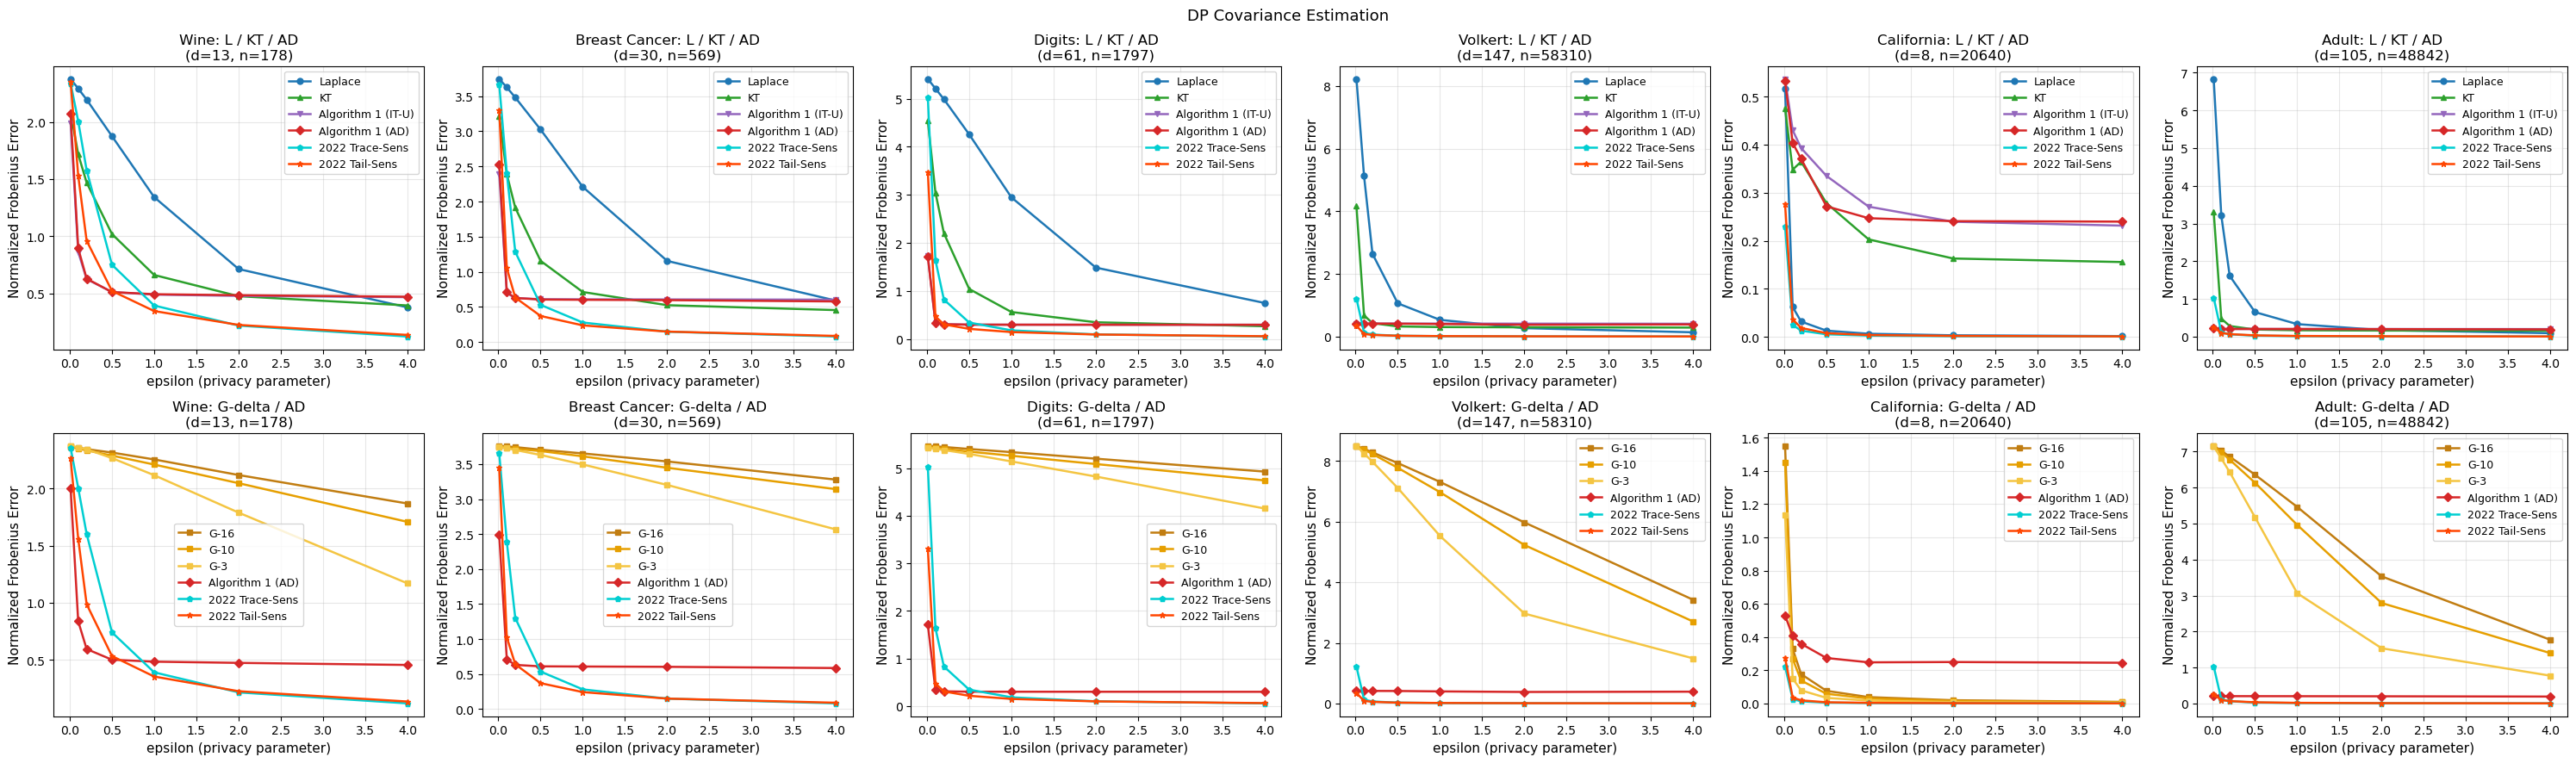

In [ ]:
# ---------------------------------------------------------------------------
# 10. Main
# ---------------------------------------------------------------------------
if __name__ == "__main__":
    # parser = argparse.ArgumentParser(description="Run DP covariance experiments.")
    # parser.add_argument(
    #     "--sampler-mode",
    #     choices=["simple", "acg", "auto"],
    #     default="auto",
    #     help="Eigenvector sampler for KT/Alg1: Monte Carlo simple, ACG-style, or auto.",
    # )
    # args = parser.parse_args()
    # set_sampler_mode(args.sampler_mode)


    parser = argparse.ArgumentParser(description="Run DP covariance experiments.")
    parser.add_argument(
        "--sampler-mode",
        choices=["simple", "acg", "auto"],
        default="auto",
        help="Eigenvector sampler for KT/Alg1: Monte Carlo simple, ACG-style, or auto.",
    )

    args, _ = parser.parse_known_args()
    set_sampler_mode(args.sampler_mode)


    print("Loading appendix-aligned datasets...")
    print(f"Sampler mode: {SAMPLER_MODE}")
    X_wine = load_wine_appendix()
    # X_airfoil = load_airfoil_appendix()
    X_breast_cancer = load_breast_cancer_appendix()
    X_digits = load_digits_appendix()
    X_california = load_california_housing_appendix()
    X_volkert = load_volkert_appendix()

    print(f"Wine:             {X_wine.shape}")
    # print(f"Airfoil:          {X_airfoil.shape}")
    print(f"Breast Cancer:    {X_breast_cancer.shape}")
    print(f"Digits:           {X_digits.shape}")
    print(f"California:       {X_california.shape}")
    print(f"Volkert:          {X_volkert.shape}")

    DELTA = 1e-5
    N_TRIALS = 50
    ADULT_TRIALS = 50
    RUN_ADULT = False
    EPSILONS = [0.01, 0.1, 0.2, 0.5, 1.0, 2.0, 4.0]
    GAUSSIAN_DELTAS = [1e-16, 1e-10, 1e-3]

    datasets = [
        ("Wine", X_wine),
        # ("Airfoil", X_airfoil),
        ("Breast Cancer", X_breast_cancer),
        ("Digits", X_digits),
        ("Volkert", X_volkert),
        ("California", X_california),
    ]

    if True:
        X_adult = load_adult_appendix()
        print(f"Adult:   {X_adult.shape}")
        datasets.append(("Adult", X_adult))

    # Row 0: L/KT/AD panels; Row 1: G-delta/AD panels; one column per dataset
    fig, axes = plt.subplots(2, len(datasets), figsize=(5 * len(datasets), 9))
    if len(datasets) == 1:
        axes = np.array([[axes[0]], [axes[1]]], dtype=object)

    json_output = {"epsilons": EPSILONS, "gaussian_deltas": GAUSSIAN_DELTAS, "datasets": {}}

    for col, (name, X_full) in enumerate(datasets):
        k = X_full.shape[0]
        n_use = X_full.shape[1]
        n_trials = ADULT_TRIALS if name == "Adult" else N_TRIALS

        # Diagnostic: λ₁(C)·log(λ₁(C)) vs log(1/δ)/ε threshold (paper Sec 3.1)
        # Algorithm 1 beats Gaussian when λ₁(C)·log(λ₁(C)) ≤ log(1/δ)/ε
        C_diag = true_covariance(X_full)
        lam1 = float(eigh(C_diag, eigvals_only=True)[-1])
        lam1_logterm = lam1 * np.log(max(lam1, 1e-12))
        thresholds = [np.log(1.0 / DELTA) / eps for eps in EPSILONS]
        beats_gaussian = sum(1 for t in thresholds if lam1_logterm <= t)
        threshold_min = min(thresholds)
        threshold_max = max(thresholds)
        relation_all = lam1_logterm <= threshold_min
        relation_some = threshold_min < lam1_logterm <= threshold_max
        print(f"\n[{name}] d={X_full.shape[0]}, n={n_use}, k={k}")
        print(f"  λ₁(C)={lam1:.4f},  λ₁(C)·log(λ₁(C))={lam1_logterm:.4f}")
        print(f"  log(1/δ)/ε range: [{threshold_min:.2f}, {threshold_max:.2f}]")
        print(f"  Relation to threshold: λ₁(C)·log(λ₁(C)) {'<=' if relation_some or relation_all else '>'} max_ε log(1/δ)/ε")
        if relation_all:
            print("  Condition status: satisfied for all tested ε values.")
        elif relation_some:
            print(f"  Condition status: satisfied for {beats_gaussian}/{len(EPSILONS)} tested ε values.")
        else:
            print("  Condition status: not satisfied for any tested ε value.")
        res_left, res_right, timing = run_experiment_vary_eps_gaussian_grid(
            X_full,
            EPSILONS,
            n_use,
            GAUSSIAN_DELTAS,
            k,
            n_trials=n_trials,
        )

        ax_left = axes[0, col]
        ax_right = axes[1, col]
        plot_results(
            EPSILONS,
            res_left,
            "epsilon (privacy parameter)",
            f"{name}: L / KT / AD",
            ax_left,
            d=X_full.shape[0],
            n=n_use,
        )
        plot_results(
            EPSILONS,
            res_right,
            "epsilon (privacy parameter)",
            f"{name}: G-delta / AD",
            ax_right,
            d=X_full.shape[0],
            n=n_use,
        )

        # Print timing summary
        print(f"\n  [{name}] Total time (seconds):")
        for alg, t in timing.items():
            print(f"    {alg:12s}: {t:.2f}s")

        json_output["datasets"][name] = {
            "shape": list(X_full.shape),
            "k": k,
            "n_trials": n_trials,
            "results_left": {alg: [float(v) for v in vals] for alg, vals in res_left.items()},
            "results_right": {alg: [float(v) for v in vals] for alg, vals in res_right.items()},
            "timing_seconds_total": {alg: float(t) for alg, t in timing.items()},
        }

    with open("results.json", "w", encoding="utf-8") as f:
        json.dump(json_output, f, indent=2)
    print("\nSaved results.json")

    plt.suptitle("DP Covariance Estimation", fontsize=13)
    plt.tight_layout()
    plt.savefig("results.png", dpi=150, bbox_inches="tight")
    print("Saved results.png")
    plt.show()
